In [1]:
def function3(input3):
    return input3

In [2]:
def function1(input):
    return input + " Hello from function1"

def function2(input):
    output = function3("This is function 2 in between")
    return input + " " + output + " and from function2"

In [3]:
from langgraph.graph import Graph

d:\Code\Langchain\venv\Lib\site-packages\langgraph\graph\graph.py:30: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from langgraph.pregel import Channel, Pregel


In [4]:
workflow1 = Graph()

In [5]:
workflow1.add_node("function1", function1)

In [6]:
workflow1.add_node("function2", function2)

In [7]:
workflow1.add_edge("function1", "function2")

In [8]:
workflow1.set_entry_point("function1")

In [9]:
workflow1.set_finish_point("function2")

In [10]:
app1 = workflow1.compile()

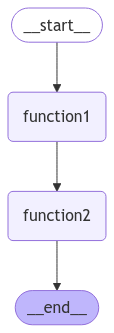

In [11]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [12]:
app1.invoke("Hi this is Hitesh")

'Hi this is Hitesh Hello from function1 This is function 2 in between and from function2'

In [13]:
input = "Hi this hitesh"
for output in app1.stream(input):
    for key, value in output.items():
        print(f"here is output from: {key}")
        print("_________")
        print(value)
        print("\n")

here is output from: function1
_________
Hi this hitesh Hello from function1


here is output from: function2
_________
Hi this hitesh Hello from function1 This is function 2 in between and from function2




### **Workflow with LLM**

In [14]:
import os
from dotenv import load_dotenv, find_dotenv 
_ = load_dotenv(find_dotenv())
openai_api_key = os.environ["OPENAI_API_KEY"]

In [15]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings 
embeddings = OpenAIEmbeddings() 
llm = ChatOpenAI()

In [16]:
def function1(input):
    llm = ChatOpenAI() 
    response = llm.invoke(input).content 
    return response

In [17]:
def function2(input):
    upper_case = input.upper() 
    return upper_case

In [18]:
from langgraph.graph import Graph 
workflow2 = Graph()

In [19]:
workflow2.add_node("llm", function1)

In [20]:
workflow2.add_node("Upper_string", function2) 

In [21]:
workflow2.add_edge("llm", "Upper_string")

In [22]:
workflow2.set_entry_point("llm")
workflow2.set_finish_point("Upper_string")

In [23]:
app2 = workflow2.compile()

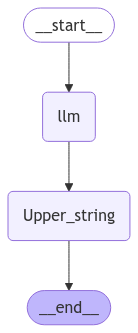

In [24]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [25]:
print(app2.invoke("What is GPU ?"))

GPU STANDS FOR GRAPHICS PROCESSING UNIT. IT IS A SPECIALIZED ELECTRONIC CIRCUIT THAT IS DESIGNED TO RAPIDLY MANIPULATE AND ALTER MEMORY TO ACCELERATE THE CREATION OF IMAGES IN A FRAME BUFFER INTENDED FOR OUTPUT TO A DISPLAY DEVICE. GPUS ARE COMMONLY USED IN GAMING, VIDEO EDITING, AND OTHER GRAPHICS-INTENSIVE APPLICATIONS TO ENHANCE THE VISUAL QUALITY AND PERFORMANCE OF IMAGES AND VIDEOS. THEY ARE ALSO USED IN MACHINE LEARNING AND ARTIFICIAL INTELLIGENCE APPLICATIONS FOR PARALLEL PROCESSING TASKS.


In [26]:
input = "What is Graphic card, Explain properly"
for output in app2.stream(input):
    for key, value in output.items():
        print(f"here is output from: {key}")
        print("_________")
        print(value)
        print("\n")

here is output from: llm
_________
A graphic card, also known as a video card or graphics processing unit (GPU), is a hardware component in a computer that is responsible for rendering images, videos, and graphics onto a display screen. It is essential for tasks that require high-quality graphics performance, such as gaming, video editing, and graphic design.

The graphic card works by processing and manipulating data to create images that can be displayed on a monitor. It contains a specialized processor that is designed to handle complex calculations and render graphics quickly and efficiently. The graphic card also has its own memory, known as video memory, which is used to store and access data needed for rendering images.

Graphic cards come in various types and models, each with different levels of performance and features. They can be integrated into the computer's motherboard or added as a separate card that plugs into a PCIe slot. High-end graphic cards are typically equipped 

### **Token Counter**

In [27]:
def function3(input):
    token = input.split()
    token_number = len(token)
    token_number = f"Total token number is {token_number}"
    return token_number

In [28]:
workflow3 = Graph() 
workflow3.add_node("llm", function1) 
workflow3.add_node("token_counter", function3)
workflow3.add_edge("llm", "token_counter")
workflow3.set_entry_point("llm")
workflow3.set_finish_point("token_counter")
app3 = workflow3.compile()

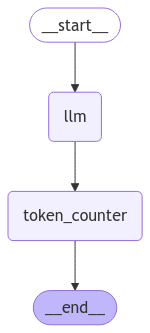

In [29]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [30]:
app3.invoke("Why we use GPU in deep learning ?")

'Total token number is 202'

### **RAG Pipeline Integration**

In [45]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader 
from langchain.text_splitter import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import Chroma

loader = TextLoader("D:\\Code\\Langchain\\data\\demo.txt", encoding='utf-8')
docs = loader.load()

### Creating Chunks using RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100, 
    chunk_overlap = 10, 
    length_function = len
)

new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [47]:
db = Chroma.from_documents(new_docs, embeddings) 
retriever = db.as_retriever(search_kwargs = {"k":4})

In [49]:
query = "Tell me about llama 3 ?"
docs = retriever.get_relevant_documents(query)
print(docs)

[Document(metadata={'source': 'D:\\Code\\Langchain\\data\\demo.txt'}, page_content='Llama 3 is one of the leading state of the art open source large language model released by Meta in'), Document(metadata={'source': 'D:\\Code\\Langchain\\data\\demo.txt'}, page_content='In this article I explore the architecture of Llama building upon the foundation of the transformer'), Document(metadata={'source': 'D:\\Code\\Langchain\\data\\demo.txt'}, page_content='llama is grouped multi query attention. This is based on multi query attention which was introduced'), Document(metadata={'source': 'D:\\Code\\Langchain\\data\\demo.txt'}, page_content='One of the major change in the llama models as compared to the transformer is the normalization')]


### **LLM RAG Workflow**

In [50]:
llm = ChatOpenAI() 
embeddings = OpenAIEmbeddings() 

In [51]:
from langchain_core.output_parsers import StrOutputParser 
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough 
from langchain.chains import RetrievalQA

In [52]:
# assign AgentState as an empty dict
AgentState = {} 

# messages key will be assigned as an empty array. We will append new messages as we pass along nodes. 
AgentState["message"] = []

In [53]:
AgentState

{'message': []}

In [75]:
AgentState["message"] = "Hello world"

In [76]:
def function_1(AgentState):
    message = AgentState["message"]
    question = message[-1] 
    complete_prompt = "Your task is to provide only the brief answer based on the user query. Dont include too much reasoning. Following is the query: " + question 

    response = llm.invoke(complete_prompt)
    AgentState["message"].append(response.content) # Appending LLM Call response to the AgentState 
    return AgentState


In [77]:
def function_2(AgentState):
    message = AgentState["message"]
    question = message[0] # Fetching the user question 

    template = """Answer the question based only on the following context: {context} 
    
    Question : {question}"""

    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context" : retriever, "question": RunnablePassthrough()} 
        | prompt 
        | llm
        | StrOutputParser()
    )
    result = retrieval_chain.invoke(question)
    return result

In [78]:
# Define a Langchain graph
workflow = Graph()

workflow.add_node("Agent", function_1) 
workflow.add_node("tool", function_2)

workflow.add_edge("Agent", "tool")

workflow.set_entry_point("Agent")
workflow.set_finish_point("tool")

app = workflow.compile()


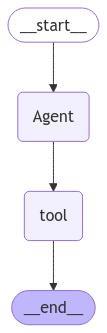

In [79]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [80]:
inputs = {"message": ["Tell me about llama 3"]}
app.invoke(inputs)

'Llama 3 is one of the leading state of the art open source large language model released by Meta. It builds upon the foundation of the transformer architecture and features grouped multi query attention, which is a major change compared to the transformer model.'

In [81]:
inputs = {"message": ["Sizes of llama model"]}
app.invoke(inputs)

'The sizes of the llama model are not mentioned in the provided context.'

In [82]:
for output in app.stream(inputs):
    # stream() yields dictionaries with output keyed by node name
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'Agent':
---
{'message': ['Sizes of llama model', 'The sizes of llama models vary, typically ranging from small (6-8 inches) to large (12-16 inches).', 'The sizes of llama models typically range from small (6-8 inches) to large (12-16 inches).']}

---

Output from node 'tool':
---
The size of the llama model is not provided in the given context.

---



In [83]:
loader2 = TextLoader("D:\\Code\\Langchain\\data\\llms.txt", encoding="utf-8")
docs = loader2.load()

In [84]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100, 
    chunk_overlap = 50
)

new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [87]:
db2 = Chroma.from_documents(new_docs, embeddings)
retriever2 = db2.as_retriever(search_kwargs = {"k": 3})

In [89]:
query = "Large Language Models"
docs = retriever2.get_relevant_documents(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': 'D:\\Code\\Langchain\\data\\demo.txt'}
architecture and why it has earned its reputation as one of the best large language models
page_content='architecture and why it has earned its reputation as one of the best large language models' metadata={'source': 'D:\\Code\\Langchain\\data\\demo.txt'}
page_content='(NLP), Google has developed influential models like BERT, T5, and PaLM (Pathways Language Model).' metadata={'source': 'D:\\Code\\Langchain\\data\\llms.txt'}
page_content='Large Language Models (LLMs) represent one of the most transformative advancements in artificial' metadata={'source': 'D:\\Code\\Langchain\\data\\llms.txt'}


In [136]:
from typing import TypedDict, Annotated, Sequence 
import operator 
from langchain_core.messages import BaseMessage 
from langchain.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain.output_parsers import PydanticOutputParser

In [137]:
class TopicSelectionParser(BaseModel):
    Topic : str = Field(description="Selected Topic")
    Reasoning : str = Field(description="Reasoning behind topic selection") 

parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [138]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage], operator.add]

In [149]:
def function_1(state):
    print('-> Calling Agent ->')
    messages = state['messages']
    question = messages[-1]   ## Fetching the user question
    
    templete = """ Your task is to provide only the topic based on the user query. 
        Only output the topic among: [Japan , Sports , Not Related]. Don't include reasoning. Following is the user query:  {question}
        {format_instructions} """
    prompt = PromptTemplate(template=templete,
                                    input_variables=[question],
                                    partial_variables={
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain = prompt | llm | parser

    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })

    print(response)

    return {"messages": [response.Topic]}


In [150]:
def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [151]:
def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with you knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [152]:
def router(state):
    print('-> Router ->')
    
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'Japan' in last_message or 'Sports' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

In [153]:
from langgraph.graph import StateGraph,END

graph = StateGraph(AgentState) ### StateGraph with AgentState

graph.add_node("agent", function_1)
graph.add_node("RAG", function_2)
graph.add_node("LLM", function_3)

graph.set_entry_point("agent")

In [154]:
# conditional edges are controlled by our router
graph.add_conditional_edges(
    "agent",  # where in graph to start
    router,  # function to determine which node is called
    {
        'RAG Call': "RAG",
        'LLM Call': "LLM",
    }
)

In [155]:
graph.add_edge("RAG", END)
graph.add_edge("LLM", END)

app = graph.compile()

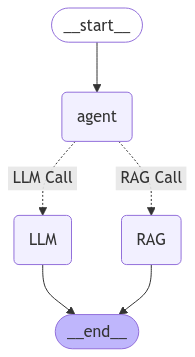

In [156]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [157]:
inputs = {"messages": ["Tell me about Large Language Models ?"]}
out = app.invoke(inputs)

-> Calling Agent ->
Topic='Not Related' Reasoning='Large Language Models are not directly related to Japan or Sports.'
-> Router ->
Not Related
-> Calling LLM ->


In [122]:
out

{'messages': ['Tell me about Large Language Models',
  'Not Related',
  'Large Language Models are a type of artificial intelligence model that are designed to understand and generate human language. These models are trained on massive amounts of text data in order to improve their language processing capabilities. Some well-known examples of Large Language Models include GPT-3 (Generative Pre-trained Transformer 3) and BERT (Bidirectional Encoder Representations from Transformers). These models have been used in various applications such as natural language processing, text generation, and chatbots. However, there are also concerns about the ethical implications of deploying such powerful language models, including issues related to bias, misinformation, and privacy.']}

In [123]:
out['messages']

['Tell me about Large Language Models',
 'Not Related',
 'Large Language Models are a type of artificial intelligence model that are designed to understand and generate human language. These models are trained on massive amounts of text data in order to improve their language processing capabilities. Some well-known examples of Large Language Models include GPT-3 (Generative Pre-trained Transformer 3) and BERT (Bidirectional Encoder Representations from Transformers). These models have been used in various applications such as natural language processing, text generation, and chatbots. However, there are also concerns about the ethical implications of deploying such powerful language models, including issues related to bias, misinformation, and privacy.']

In [158]:
inputs = {"messages": ["Tell me about Artificial Intelligence"]}
out = app.invoke(inputs)

-> Calling Agent ->
Topic='Not Related' Reasoning='The user query does not specifically mention any particular topic'
-> Router ->
Not Related
-> Calling LLM ->


In [159]:
out

{'messages': ['Tell me about Artificial Intelligence',
  'Not Related',
  'Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. AI involves the development of algorithms that enable machines to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.\n\nAI has a wide range of applications across various industries, including healthcare, finance, transportation, and entertainment. It is used in chatbots, virtual assistants, self-driving cars, and recommendation systems, among others.\n\nThere are different types of AI, including narrow AI (or weak AI), which is designed for a specific task, and general AI (or strong AI), which is able to perform any intellectual task that a human can do.\n\nAI has the potential to revolutionize many aspects of our lives, but it also raises ethical concerns related to privacy, security, and